# Determining electric conductivity $\sigma$ and magnetic field $B$

### Imports

In [21]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error


from python_utils.utils import load_object

from python_utils.time_series_extraction import extract_timeseries
from python_utils.time_series_extraction import find_matching_row_index_from_timeseries
from python_utils.time_series_extraction import plot_timeseries

from python_utils.data_processing import print_loaded_data_example

from python_utils.sigma_and_b_estimation import calc_conductivity_with_z_at_site

### General Args

In [22]:
# slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
slice_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates from evaluations
sigma = -1
B_z = -1

### Load Data

In [23]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [24]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
    fld_timeseries = fld_data['timeseries']
    fld_labels = fld_data['labels']
print_loaded_data_example(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
    gradF_timeseries = gradF_data['timeseries']
    gradF_labels = gradF_data['labels']
print_loaded_data_example(gradF_data)

The data looks as follows:
N = 20000
n_y = 49.0, n_z = 49.0, n_v = 10
Labels:
['y', 'z', 'vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
[[-1.        -1.         0.       ]
 [-0.9882464 -1.         0.       ]
 [-0.9697327 -1.         0.       ]
 [-0.9446967 -1.         0.       ]
 [-0.9135254 -1.         0.       ]]

The data looks as follows:
N = 20000
n_y = 49.0, n_z = 49.0, n_v = 5
Labels:
['y', 'z', 'dfdx', 'dfdy', 'dfdz']
[[-1.        -1.         0.2709205]
 [-0.9882464 -1.         0.2637546]
 [-0.9697327 -1.         0.537164 ]
 [-0.9446967 -1.         1.208979 ]
 [-0.9135254 -1.         2.61423  ]]


### Ohm's Law

$\mathbf{J} = \sigma (\mathbf{E} + \mathbf{v} \times \mathbf{B})$

In vector form:

$\mathbf{J} = \begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \begin{pmatrix} E_x + (v_y B_z - v_z B_y) \\ E_y + (v_z B_x - v_x B_z) \\ E_z + (v_x B_y - v_y B_x) \end{pmatrix}$

We know that $B$ is only present in $z$-direction.

$\begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \left(\begin{pmatrix}E_x \\ E_y \\ E_z \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\partial \varphi}{\partial x} \\ \frac{\partial \varphi}{\partial y} \\ \frac{\partial \varphi}{\partial 
z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$\approx \sigma \left(\begin{pmatrix} \frac{\Delta \varphi_x}{\Delta l_x} \\ \frac{\Delta \varphi_y}{\Delta l_y} \\ \frac{\Delta \varphi_z}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \\ \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} \\ \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

So, we have:

$ v_y \approx \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \right) $

$ v_x \approx \frac{1}{B_z} \left( \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} - \frac{j_y}{\sigma} \right) $

$ \frac{j_z}{\sigma} \approx \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z}$

### Get Existing x and y Coordinates

In [18]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired

# Ha = 300
# y_coord = -0.01842125
# z_coord = -0.01842125

# Ha = 1000
y_coord = 0
z_coord = 0

i_center = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=y_coord,
    z_coord=z_coord,
    )

## Ohm's Law in z-coord

### Calculate Sigma

In [ ]:
def calc_conductivity_field_with_z(): # TODO

In [19]:
sigma_est_ts = calc_conductivity_with_z_at_site(
        partial_phi_data=gradF_data,
        partial_phi_label='dfdz',
        current_data=fld_data,
        current_label='jz',
        y_coord=y_coord,
        z_coord=z_coord,
        print_statistics=True,
        )
# plot_timeseries(
#     sigma_est_ts,
#     )

mean(conductivity estimate) = -1.0
std(conductivity estimate) = 0.0
median(conductivity estimate) = -1.0


### Error in z

In [20]:
sigma_est_round = -1

part_phi_z = extract_timeseries(
    data=gradF_data,
    column_labels='dfdz',
    y_coord=y_coord,
    z_coord=z_coord,
    )
j_z_center = extract_timeseries(
    data=fld_data,
    column_labels='jz',
    y_coord=y_coord,
    z_coord=z_coord,
    )

print(f"mse(part_phi_z) = {mean_squared_error(part_phi_z, j_z_center / sigma_est_round)}")

# plot_timeseries(
#     data_list=[
#         # part_phi_z,
#         part_phi_z - j_z_center / sigma_est_round,
#         ],
#     labels=[
#         # "$\\frac{\\partial{\\phi}}{\\partial{z}}$",
#         "err",
#         ],
#     linewidth=0.7,
#     )

mse(part_phi_z) = 0.0


### Plot $v_x$

In [16]:
v_x_center = extract_timeseries(
    data=fld_data,
    column_labels='vx',
    y_coord=y_coord,
    z_coord=z_coord,
    )

### Estimate $B_z$

mean(B_z_est) = -0.9980944827931048
std(B_z_est) = 0.2520174405433839
median(B_z_est) = -0.9999044973269932


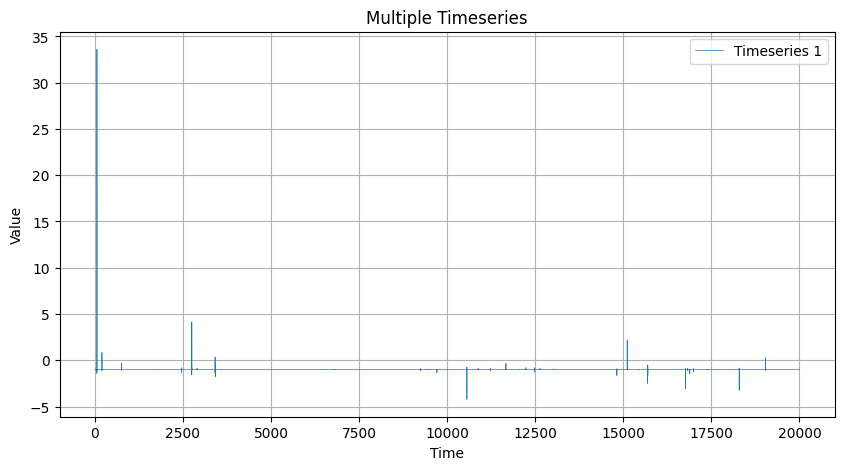

In [17]:
part_phi_y = extract_timeseries(
    data=gradF_data,
    column_labels="dfdy",
    y_coord=y_coord,
    z_coord=z_coord,
    )
j_y_center = extract_timeseries(
    data=fld_data,
    column_labels='jy',
    y_coord=y_coord,
    z_coord=z_coord,
    )
B_z_est = np.divide(
    part_phi_y - j_y_center / sigma,
    # part_phi_y,
    v_x_center,
    )

print(f"mean(B_z_est) = {np.mean(B_z_est)}")
print(f"std(B_z_est) = {np.std(B_z_est)}")
print(f"median(B_z_est) = {np.median(B_z_est)}")

plot_timeseries(
    B_z_est,
    linewidth=0.5,
    )

### Estimate Sigma

mean(sigma_est) = -0.5244395120905921
std(sigma_est) = 70.96016534811481
median(sigma_est) = -0.9719540985390813


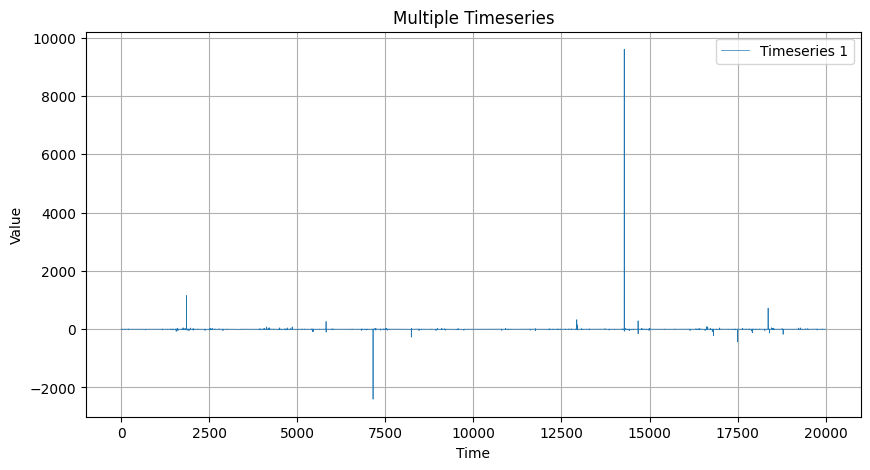

In [18]:
sigma_est = np.divide(
    j_y_center,
    part_phi_y - v_x_center * B_z,
    )

print(f"mean(sigma_est) = {np.mean(sigma_est)}")
print(f"std(sigma_est) = {np.std(sigma_est)}")
print(f"median(sigma_est) = {np.median(sigma_est)}")
plot_timeseries(
    sigma_est,
    linewidth=0.5,
    )